<a href="https://colab.research.google.com/github/claraluchiari/Machine_Learning/blob/main/reg_logistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay

In [2]:
iris = load_iris(as_frame = True)

df = iris.frame

labels = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}

# Acrescenta a coluna 'labels' mapeando os valores de 'target' conforme o dicionário criado
df['labels'] = df['target'].map(labels)

#isola os nomes das classes
class_names = df['labels'].unique()

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,labels
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
#extrai do DataFrame um array com as 150 amostras representadas por seus 4 atributos
X = df.iloc[:,:4].values
#extrai do DataFrame um array com os labels
y = df["target"].values

print(f"Dataset de entrada: {X.shape}")
print(f"Tipo do conjunto de entrada: {type(X)}")
print(f"Dataset de saída: {y.shape}")
print(f"Tipo do conjunto de saída: {type(y)}")

Dataset de entrada: (150, 4)
Tipo do conjunto de entrada: <class 'numpy.ndarray'>
Dataset de saída: (150,)
Tipo do conjunto de saída: <class 'numpy.ndarray'>


In [4]:
#opção: stratify = y - separa as amostras mantendo a proporção que os labels originalmente têm (no caso, 1/3, 1/3 e 1/3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=0, stratify=None, shuffle=True)
print(f"Conjunto de treinamento: {X_train.shape}")
print(f"Conjunto de teste: {X_test.shape}")

Conjunto de treinamento: (112, 4)
Conjunto de teste: (38, 4)


In [8]:
lr_model = LogisticRegression(penalty= 'l2')

#Treinamento
lr_model.fit(X_train, y_train)

#Conferindo os parâmetros "ótimos" do modelo
print(f"Parâmetros do modelo: \n{lr_model.coef_}")
print(f"Classes: \n{lr_model.classes_}")

Parâmetros do modelo: 
[[-0.41360574  0.84866329 -2.33208281 -0.98859015]
 [ 0.51464691 -0.2966476  -0.21718957 -0.71439614]
 [-0.10104117 -0.55201569  2.54927238  1.70298629]]
Classes: 
[0 1 2]


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      0.94      0.97        16
   virginica       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38

F1-score no conjunto de teste: 0.9717


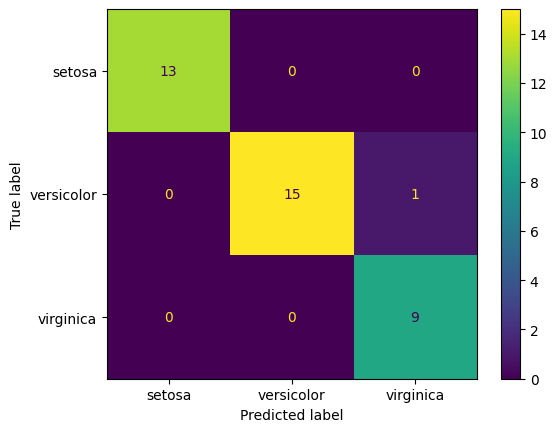

In [10]:
#Aplica a regressão logística sobre o conjunto de teste e obtém os rótulos estimados
y_pred_test = lr_model.predict(X_test)

# Obtém a matriz de confusão e outras métricas de desempenho no conjunto de teste
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred_test)

ConfusionMatrixDisplay(confmat,display_labels=class_names).plot()

print(classification_report(y_true=y_test, y_pred=y_pred_test, target_names=class_names))

print(f"F1-score no conjunto de teste: {f1_score(y_true=y_test, y_pred=y_pred_test, average='macro'):.4f}")

In [12]:
# Observando as probabilidades estimadas para cada amostra do conjunto de teste

y_probs_test = lr_model.predict_proba(X_test)

#Exibir rótulo, rótulo estimado e probabilidades obtidas para o conjunto de teste
y_res = np.hstack((y_test.reshape((y_test.size,1)), y_pred_test.reshape((y_pred_test.size,1)), np.round(y_probs_test,2)))
results_test = pd.DataFrame(y_res, columns=['Label', 'Estim.', 'Prob. Setosa', 'Prob. Versicolor', 'Prob. Virginica'])
display(results_test)

,Label,Estim.,Prob. Setosa,Prob. Versicolor,Prob. Virginica
0,2.0,2.0,0.00,0.06,0.94
1,1.0,1.0,0.01,0.96,0.03
2,0.0,0.0,0.98,0.02,0.00
3,2.0,2.0,0.00,0.02,0.98
4,0.0,0.0,0.97,0.03,0.00
5,2.0,2.0,0.00,0.01,0.99
6,0.0,0.0,0.98,0.02,0.00
7,1.0,1.0,0.00,0.75,0.25
8,1.0,1.0,0.00,0.74,0.26
9,1.0,1.0,0.02,0.94,0.04
